# Customer Churn Prediction — Machine Learning Project
مشروع تصنيف باستخدام Machine Learning للتنبؤ بمغادرة العملاء (Customer Churn) لشركة اتصالات، باستخدام بيانات Telco Customer Churn من Kaggle.

In [1]:
# الخطوة 1: ربط Google Drive بالكولاب
# هذا السطر يفتح نافذة تطلب منك تسجيل الدخول والسماح للكولاب بالوصول لملفات Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Data Loading & Exploration (EDA)
تحميل البيانات من Google Drive، واستكشاف أولي لفهم شكلها وأنواعها.

In [2]:
# الخطوة 2: قراءة ملف الـ CSV من مسار الدرايف اللي حددناه
import pandas as pd

# نحدد المسار الكامل للملف بناءً على مكان تواجده بالدرايف
path = '/content/drive/My Drive/Customer-Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# نقرأ الملف ونخزنه في متغير اسمه df (اختصار DataFrame، وهو الشكل اللي pandas يخزن فيه الجداول)
df = pd.read_csv(path)

# نطبع أول 5 صفوف نتأكد إن القراءة نجحت
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# الخطوة 3: نظرة عامة على شكل البيانات وأنواعها

# .shape يعطينا عدد الصفوف والأعمدة بسرعة
print("عدد الصفوف والأعمدة:", df.shape)
print()

# .info() يعطينا نوع كل عمود (رقمي / نصي) وعدد القيم غير الفارغة في كل عمود
# هذا يساعدنا نكتشف القيم المفقودة أو الأعمدة اللي نوعها غير متوقع
df.info()

عدد الصفوف والأعمدة: (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperless

In [4]:
# الخطوة 4: إحصائيات وصفية للأعمدة الرقمية فقط
# .describe() يعطينا: المتوسط، الانحراف المعياري، أصغر وأكبر قيمة... إلخ
# هذا يساعدنا نكتشف القيم الشاذة (Outliers) أو أرقام غير منطقية
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Cleaning
تحويل عمود TotalCharges لرقمي وتعويض القيم الناقصة بصفر

In [5]:
# الخطوة 5: فحص عمود TotalCharges عن قرب
# نحاول نحول العمود لأرقام، وأي قيمة ما تقدر تتحول تتحول لـ NaN تلقائياً
# errors='coerce' معناها: "لو واجهت قيمة ما تقدر تحولها لرقم، حطها NaN بدل ما توقف بخطأ"
temp_check = pd.to_numeric(df['TotalCharges'], errors='coerce')

# نعد كم قيمة تحولت لـ NaN (يعني كانت غير رقمية أصلاً)
print("عدد القيم غير الرقمية بعمود TotalCharges:", temp_check.isnull().sum())

# نعرض الصفوف اللي فيها هذي المشكلة عشان نشوف شكلها
df[temp_check.isnull()]

عدد القيم غير الرقمية بعمود TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [6]:
# الخطوة 6: تنظيف عمود TotalCharges

# أولاً: نحول العمود فعلياً لرقمي (float)
# نفس الطريقة اللي جربناها قبل، لكن هذي المرة نطبقها على df الأصلي مباشرة
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ثانياً: أي قيمة صارت NaN (وهي الـ 11 صف اللي اكتشفناها) نعوضها بصفر
# .fillna(0) تعني: "أي قيمة فاضية (NaN) بهذا العمود، عوضها بالرقم 0"
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# نتأكد إن التحويل نجح: نشوف نوع العمود الجديد
print("نوع عمود TotalCharges الآن:", df['TotalCharges'].dtype)

# نتأكد ما فيه قيم مفقودة متبقية بأي عمود بكل الجدول
print()
print("إجمالي القيم المفقودة بكل الأعمدة:")
print(df.isnull().sum().sum())

نوع عمود TotalCharges الآن: float64

إجمالي القيم المفقودة بكل الأعمدة:
0


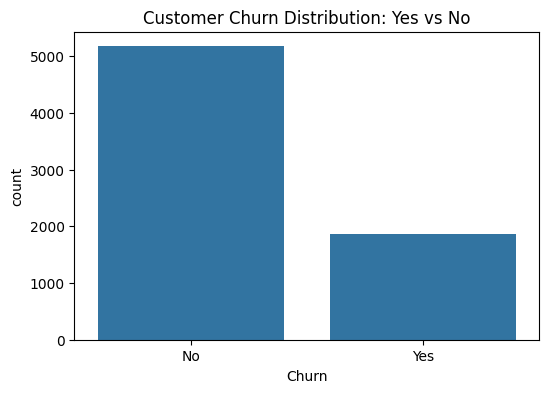

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [7]:
# الخطوة 7: تصور توزيع الـ Target (Churn) بصرياً
import matplotlib.pyplot as plt
import seaborn as sns

# نحدد حجم الرسمة (العرض 6، الارتفاع 4)
plt.figure(figsize=(6,4))

# countplot يرسم عدد التكرارات لكل فئة (Yes/No) بشكل أعمدة
sns.countplot(data=df, x='Churn')

# عنوان الرسمة بالإنجليزي عشان يظهر بشكل صحيح بدون مشاكل اتجاه النص
plt.title('Customer Churn Distribution: Yes vs No')

# نعرض الرسمة
plt.show()

# نطبع كمان النسب المئوية الدقيقة تحت الرسمة
print(df['Churn'].value_counts(normalize=True) * 100)

## 3. Feature Engineering (Encoding)
حذف customerID، ثم تحويل الأعمدة النصية لأرقام: Label Encoding للأعمدة الثنائية، One-Hot Encoding للأعمدة متعددة القيم.

In [8]:
# الخطوة 8: حذف عمود customerID لأنه معرّف فريد وما له قيمة تنبؤية
df = df.drop('customerID', axis=1)

# نتأكد من عدد الأعمدة المتبقية
print("عدد الأعمدة بعد الحذف:", df.shape[1])

عدد الأعمدة بعد الحذف: 20


In [9]:
# الخطوة 9: تحويل الأعمدة الثنائية (فيها قيمتين بس: Yes/No) لأرقام 0 و 1

# نحدد قائمة بالأعمدة الثنائية اللي قيمتها Yes/No فقط
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# نمر على كل عمود بالقائمة، ونستبدل Yes بـ 1 و No بـ 0
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# عمود gender منفصل لأن قيمه Male/Female مو Yes/No
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# نتأكد من النتيجة
df[binary_cols + ['gender']].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn,gender
0,1,0,0,1,0,0
1,0,0,1,0,0,1
2,0,0,1,1,1,1
3,0,0,0,0,0,1
4,0,0,1,1,1,0


In [10]:
# الخطوة 10: تطبيق One-Hot Encoding على باقي الأعمدة النصية

# pd.get_dummies() تسوي تلقائياً One-Hot Encoding لأي عمود نصي تحدده
# drop_first=True: نحذف أول فئة من كل عمود (لتفادي التكرار الزائد بين الأعمدة - مصطلح نشرحه تحت)
df = pd.get_dummies(df, drop_first=True)

# نتأكد من الشكل النهائي: كم عمود صار عندنا الآن؟
print("عدد الأعمدة النهائي بعد Encoding:", df.shape[1])

# نطبع أسماء كل الأعمدة نتأكد الشكل صحيح
print(df.columns.tolist())

عدد الأعمدة النهائي بعد Encoding: 31
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## 4. Train/Test Split & Feature Scaling
تقسيم البيانات إلى تدريب واختبار (80/20) مع الحفاظ على توازن الفئات (Stratify)، ثم توحيد مقياس الأعمدة الرقمية (Feature Scaling) لحل مشكلة عدم التقارب (Convergence) في النموذج.


In [11]:
# الخطوة 11: فصل الأعمدة (Features) عن الهدف (Target)، ثم تقسيم البيانات

from sklearn.model_selection import train_test_split

# X = كل الأعمدة ما عدا Churn (هذي الـ "Features" اللي النموذج بيستخدمها للتنبؤ)
X = df.drop('Churn', axis=1)

# y = عمود Churn لحاله (هذا الـ "Target" اللي نبي نتنبأ فيه)
y = df['Churn']

# نقسّم البيانات: 80% تدريب، 20% اختبار
# test_size=0.2 يعني 20% للاختبار
# random_state=42 يثبت طريقة التقسيم العشوائي، عشان لو أعدنا تشغيل الكود نحصل نفس التقسيم بالضبط (مهم لإعادة الإنتاج)
# stratify=y يضمن إن نسبة Churn (Yes/No) تكون متشابهة بكل من مجموعتي التدريب والاختبار (مهم جداً لأن بياناتنا Imbalanced!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# نتأكد من حجم كل مجموعة
print("حجم بيانات التدريب:", X_train.shape)
print("حجم بيانات الاختبار:", X_test.shape)

# نتأكد إن نسبة Churn متشابهة بالمجموعتين (بسبب stratify)
print()
print("نسبة Churn في التدريب:")
print(y_train.value_counts(normalize=True))
print()
print("نسبة Churn في الاختبار:")
print(y_test.value_counts(normalize=True))

حجم بيانات التدريب: (5634, 30)
حجم بيانات الاختبار: (1409, 30)

نسبة Churn في التدريب:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

نسبة Churn في الاختبار:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 5. Model Training & Evaluation
تدريب وتقييم ثلاثة نماذج تصنيف مختلفة: Logistic Regression (Baseline)، Random Forest، وLogistic Regression مع class_weight='balanced' لمعالجة عدم توازن الفئات (Imbalanced Classes).

In [12]:
# الخطوة 12: بناء وتدريب نموذج Logistic Regression

from sklearn.linear_model import LogisticRegression

# ننشئ كائن (Object) من النموذج
# max_iter=1000: نزيد عدد محاولات التحسين الداخلية للنموذج (أحياناً القيمة الافتراضية ما تكفي عشان النموذج "يتقارب" على حل جيد)
model = LogisticRegression(max_iter=1000)

# .fit() هي خطوة "التدريب" الفعلية: النموذج يتعلم الأنماط من بيانات التدريب فقط
model.fit(X_train, y_train)

print("تم تدريب النموذج بنجاح! ✅")

تم تدريب النموذج بنجاح! ✅


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# الخطوة 13: تطبيق Feature Scaling على الأعمدة الرقمية

from sklearn.preprocessing import StandardScaler

# نحدد الأعمدة الرقمية غير الثنائية اللي تحتاج توحيد مقياس
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# ننشئ كائن الـ Scaler
scaler = StandardScaler()

# .fit_transform() على التدريب: نتعلم (fit) المتوسط والانحراف المعياري من Train فقط، ثم نطبقهم (transform) عليه
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# .transform() فقط على الاختبار: نطبق نفس المقاييس اللي تعلمناها من Train، بدون ما نعيد التعلم
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# نتأكد بصرياً من النتيجة
print("عينة من بيانات التدريب بعد Scaling:")
X_train[numeric_cols].describe()

عينة من بيانات التدريب بعد Scaling:


,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


In [14]:
# الخطوة 14: إعادة تدريب النموذج بعد Feature Scaling

from sklearn.linear_model import LogisticRegression

# ننشئ نموذج جديد (نفس الإعدادات القديمة)
model = LogisticRegression(max_iter=1000)

# نعيد التدريب، لكن هذي المرة X_train فيه الأعمدة الرقمية بعد التوحيد
model.fit(X_train, y_train)

print("تم تدريب النموذج بنجاح! ✅")

تم تدريب النموذج بنجاح! ✅


In [15]:
# الخطوة 15: توليد التنبؤات على بيانات الاختبار

# .predict() يستخدم النموذج المدرّب عشان يتنبأ بـ Churn لكل صف في X_test
# مهم: X_test لم يشاهده النموذج أثناء التدريب إطلاقاً
y_pred = model.predict(X_test)

# نطبع أول 10 تنبؤات كعينة سريعة
print("أول 10 تنبؤات:", y_pred[:10])
print("أول 10 قيم حقيقية:", y_test[:10].values)

أول 10 تنبؤات: [0 1 0 0 0 1 0 0 0 0]
أول 10 قيم حقيقية: [0 0 0 0 0 0 0 0 0 1]


In [16]:
# الخطوة 16: تقييم النموذج بمقاييس شاملة

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Accuracy: نسبة التنبؤات الصحيحة من إجمالي التنبؤات
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision: من كل من توقعنا Churn=1، كم فعلاً كان Churn=1؟
print("Precision:", precision_score(y_test, y_pred))

# Recall: من كل من فعلاً Churn=1، كم قدرنا نكتشفه؟
print("Recall:", recall_score(y_test, y_pred))

# F1-score: التوازن بين Precision و Recall
print("F1-score:", f1_score(y_test, y_pred))

print()
# Confusion Matrix: جدول تفصيلي يوضح التنبؤات الصح والغلط لكل فئة
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print()
# classification_report يلخص كل المقاييس أعلاه بجدول واحد مرتب
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8062455642299503
Precision: 0.6593059936908517
Recall: 0.5588235294117647
F1-score: 0.6049204052098408

Confusion Matrix:
[[927 108]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [17]:
# الخطوة 17: بناء وتدريب نموذج Random Forest

from sklearn.ensemble import RandomForestClassifier

# ننشئ النموذج
# n_estimators=100: عدد الأشجار داخل الـ "الغابة" (100 شجرة قرار مختلفة تصوّت مع بعض)
# random_state=42: لضمان نفس النتيجة لو أعدنا التشغيل (إعادة الإنتاج)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# نفس خطوة التدريب اللي سويناها قبل، بس هذي المرة بنموذج مختلف
rf_model.fit(X_train, y_train)

print("تم تدريب نموذج Random Forest بنجاح! ✅")

تم تدريب نموذج Random Forest بنجاح! ✅


In [18]:
# الخطوة 18: توليد التنبؤات وتقييم Random Forest

# نولّد التنبؤات بنفس طريقة النموذج الأول، لكن بنموذج rf_model
y_pred_rf = rf_model.predict(X_test)

# نفس مقاييس التقييم بالضبط، لضمان مقارنة عادلة
print("=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.7842441447835344
Precision: 0.6215277777777778
Recall: 0.4786096256684492
F1-score: 0.540785498489426

Confusion Matrix:
[[926 109]
 [195 179]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## 6. Model Interpretation (Feature Importance)
استخراج وتحليل معاملات نموذج Logistic Regression لفهم أهم العوامل المؤثرة على قرار مغادرة العميل (Churn).

In [19]:
# الخطوة 19: استخراج وترتيب معاملات النموذج (Feature Importance)

# .coef_ يعطينا معاملات كل عمود كمصفوفة، ناخذ العنصر الأول [0] لأنها مشكلة تصنيف ثنائي
coefficients = model.coef_[0]

# ننشئ جدول (DataFrame) يربط اسم كل عمود بمعامله، عشان يكون منظم وسهل القراءة
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients
})

# نرتب الجدول تنازلياً حسب القيمة المطلقة للمعامل (أهم الأعمدة، سواء موجبة أو سالبة، تطلع فوق)
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

# نطبع أهم 10 أعمدة تأثيراً
print(feature_importance[['Feature', 'Coefficient']].head(10))

                           Feature  Coefficient
26               Contract_Two year    -1.313803
4                           tenure    -1.257131
11     InternetService_Fiber optic     1.180666
25               Contract_One year    -0.683857
8                     TotalCharges     0.527772
5                     PhoneService    -0.520750
7                   MonthlyCharges    -0.466504
28  PaymentMethod_Electronic check     0.392775
22                 StreamingTV_Yes     0.374831
6                 PaperlessBilling     0.374218


In [20]:
# الخطوة 20: تدريب نموذج Logistic Regression جديد بـ class_weight='balanced'

# نفس النموذج السابق، بس نضيف class_weight='balanced'
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

# نفس خطوة التدريب
model_balanced.fit(X_train, y_train)

# نولد التنبؤات
y_pred_balanced = model_balanced.predict(X_test)

# نقيّم بنفس المقاييس بالضبط، للمقارنة العادلة
print("=== Logistic Regression (Balanced) Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1-score:", f1_score(y_test, y_pred_balanced))

print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

=== Logistic Regression (Balanced) Results ===
Accuracy: 0.7381121362668559
Precision: 0.504302925989673
Recall: 0.7834224598930482
F1-score: 0.6136125654450262

Confusion Matrix:
[[747 288]
 [ 81 293]]


## 7. Conclusion & Model Comparison

تم تدريب وتقييم ثلاثة نماذج تصنيف لمشكلة التنبؤ بمغادرة العملاء (Customer Churn):

| النموذج | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|
| Logistic Regression (Baseline) | 80.6% | 65.9% | 55.9% | 60.5% |
| Random Forest | 78.4% | 62.2% | 47.9% | 54.1% |
| Logistic Regression (Balanced) | 73.8% | 50.4% | 78.3% | 61.4% |

**الملاحظات الرئيسية:**
- النموذج الأبسط (Logistic Regression) تفوق على Random Forest في جميع المقاييس تقريباً، مما يوضح أن البيانات تحتوي على علاقات شبه خطية لا تحتاج لتعقيد إضافي.
- تطبيق class_weight='balanced' على Logistic Regression حسّن Recall بشكل كبير (من 55.9% إلى 78.3%)، على حساب انخفاض في Precision — وهو Trade-off متوقع عند التعامل مع بيانات غير متوازنة (Imbalanced Classes).
- **اختيار النموذج المناسب يعتمد على السياق التجاري**: في سياق بنكي/اتصالات حيث الأولوية هي اكتشاف أكبر عدد ممكن من العملاء المعرضين للمغادرة (لتفعيل برامج الاحتفاظ)، يُفضّل نموذج Logistic Regression (Balanced) رغم انخفاض دقته الإجمالية.

**أهم العوامل المؤثرة على قرار المغادرة (من تحليل Feature Importance):**
نوع العقد (خاصة العقود طويلة الأجل) ومدة الاشتراك (tenure) هما أقوى عاملين يقللان احتمال المغادرة، بينما الاشتراك في خدمة Fiber Optic يزيد من احتمال المغادرة بشكل ملحوظ.

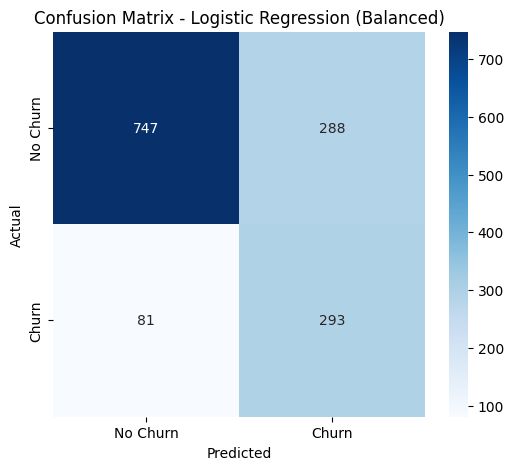

In [21]:
# رسم Confusion Matrix بصرياً كـ Heatmap للنموذج النهائي (LR Balanced)
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6,5))
# annot=True يكتب الأرقام داخل كل خانة، fmt='d' يعرضها كأعداد صحيحة
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression (Balanced)')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# نحفظ الرسمة كملف PNG بجودة عالية
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

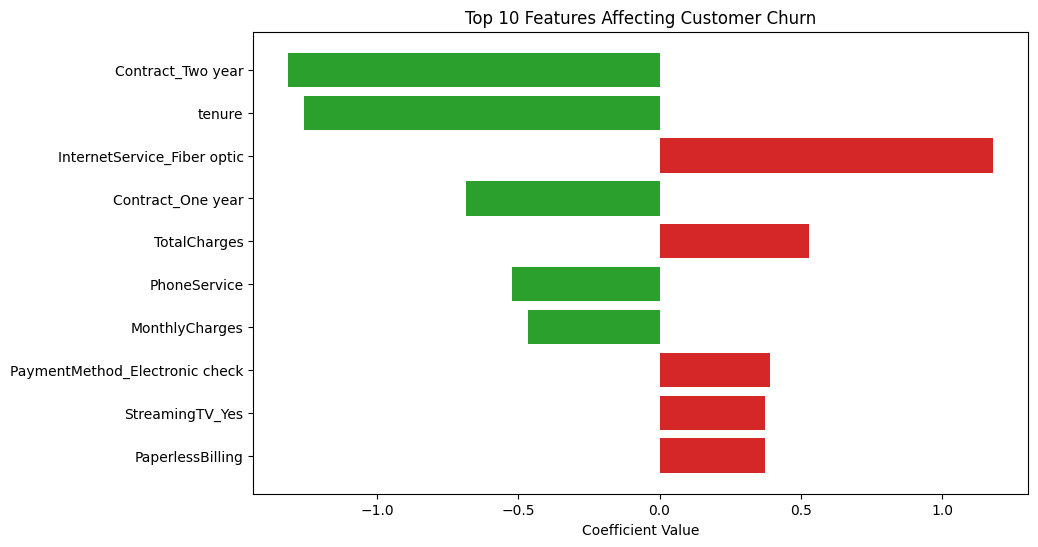

In [22]:
# رسم Feature Importance كملف PNG
plt.figure(figsize=(10,6))
top_10 = feature_importance.head(10)

# نرسم Bar Chart أفقي، ونلون حسب الاتجاه (سالب/موجب)
colors = ['#d62728' if x > 0 else '#2ca02c' for x in top_10['Coefficient']]
plt.barh(top_10['Feature'], top_10['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Features Affecting Customer Churn')
plt.gca().invert_yaxis()  # أهم عمود يطلع فوق

plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# تحميل الصورتين مباشرة لجهازك
from google.colab import files

files.download('confusion_matrix.png')
files.download('feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>